### Libraries and functions importation

In [1]:
import sys
sys.path.append("../src")


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost
import lightgbm
import catboost


from preprocessing import preprocesamiento_pre_split, preprocesamiento_post_split, onehot_encoding
from data_splitting import train_val_split
from plots import eda_visualizacion_suvs

In [2]:
#IGNORAR ESTA CELDA
%load_ext autoreload
%autoreload 2

### EDA

**Preprocessing**

In [3]:
data = pd.read_csv('../data/pf_suvs.csv')

In [4]:
print("\n Dataset ALEATORIO")
print(data.sample(5))

print("\n -------- RESUMEN - ESTADISTICOS E INFO -------- \n" )
print("\n DATA INFO")
print(data.info())



 Dataset ALEATORIO
       Unnamed: 0    Marca         Modelo     Año                 Versión  \
657           657      BMW             X3  2023.0    2.0 Xdrive 30i Xline   
16611       16611      BMW             X3  2025.0             Xdrive 20 I   
12121       12121      BMW             X5  2020.0             40i X DRIVE   
14750       14750  Citroën    C5 Aircross  2024.0  1.6 Thp Eat6 Feel Pack   
18143       18143   Toyota  Corolla Cross  2025.0        1.8 Hev Seg Ecvt   

        Color Tipo de combustible  Puertas Transmisión Motor  \
657    Blanco               Nafta      5.0  Automática   2.0   
16611   Negro               Nafta      5.0  Automática   2.0   
12121   Negro               Nafta      5.0  Automática   3.0   
14750    Gris               Nafta      5.0  Automática   1.6   
18143  Blanco       Híbrido/Nafta      5.0  Automática   1.8   

      Tipo de carrocería Con cámara de retroceso Kilómetros  \
657                  SUV                     NaN    20500.0   
16611 

In [5]:
summary = pd.DataFrame({
    "dtype": data.dtypes,
    "nulos": data.isnull().sum(),
    "unicos": data.nunique()
})
summary

,dtype,nulos,unicos
Unnamed: 0,int64,0,18254
Marca,str,0,47
Modelo,str,0,137
Año,float64,0,40
Versión,str,0,2072
Color,str,389,70
Tipo de combustible,str,0,8
Puertas,float64,0,7
Transmisión,str,15,4
Motor,str,38,271


In [6]:
print("\n DATA DESCRIPCION " )
data.describe()


 DATA DESCRIPCION 


,Unnamed: 0,Año,Puertas,Precio
count,18254.000000,18254.000000,18254.000000,1.825400e+04
mean,9126.500000,2042.796209,18.167306,1.760162e+07
std,5269.620242,3217.260996,891.766121,1.720810e+07
min,0.000000,1981.000000,2.000000,1.110000e+02
25%,4563.250000,2016.000000,5.000000,3.190000e+04
50%,9126.500000,2019.000000,5.000000,1.720000e+07
75%,13689.750000,2024.000000,5.000000,2.995000e+07
max,18253.000000,436694.000000,60252.000000,3.495000e+08


ESCRIBIR LO QEU VAMOS A HACER EJ ONE HOT POR LAS FEATURES CATEGORICAS ETC

***PREPROCESAMIENTO: Limpieza de datos necesaria para no afectar el entrenamiento del modelo.***

- solo hacer limpieza de columnas de suvs 
- pasar de de pesoss a dolar y la borramos  
- col 0 km y usados , 0  1 
- eliminamos lass filas 0 de motor 
- ponemos en puertas todo 5
- pasar con one hot a trsmision 
- borramos unnamed 
- DESCRIPCION -> CLASIFICAR
- TITULO -> BORRAR (es la concatenacion de otros features)

DESPUES DEL SPLIT
- moda de color 
- moda de camara 
- ONE HOT TIPO VENDEDOR 

In [7]:
data_pre = preprocesamiento_pre_split(data)
print('Tamaño final del dataset -> ', data_pre.shape)

Tamaño final del dataset ->  (18216, 16)


**NUEVO DATASET**

In [17]:
print("\n Dataset NUEVO, ALEATORIO")
print(data_pre.sample(5))

print("\n -------- RESUMEN - ESTADISTICOS E INFO -------- \n" )
print("\n data_pre INFO")
print(data_pre.info())
print("\n data_pre DESCRIPCION " )
print(data_pre.describe())


 Dataset NUEVO, ALEATORIO
           Marca     Modelo     Año                   Versión   Color  \
13763     Toyota  Hilux SW4  2021.0  2.8 Srx 177cv 4x4 7as At  Blanco   
3423      Toyota        SW4  2017.0  2.8 Srx 204Cv 4X4 7As At  Blanco   
10693  Chevrolet    Tracker  2024.0          1.2 Ltz Turbo At   Negro   
16112       Ford   Ecosport  2013.0          1.6 Se 110cv 4x2    Gris   
15278    Hyundai     Tucson  2017.0                   2.0 16v  Blanco   

      Tipo de combustible  Puertas            Transmisión   Motor  \
13763              Diésel      5.0             Automática     2.8   
3423               Diésel      5.0  Automática secuencial  2.8TDI   
10693               Nafta      5.0             Automática     1.2   
16112           Nafta/GNC      5.0                 Manual     1.6   
15278               Nafta      5.0                 Manual     2.0   

      Con cámara de retroceso  Kilómetros  \
13763                     NaN     58000.0   
3423                      NaN

In [18]:
summary = pd.DataFrame({
    "dtype": data_pre.dtypes,
    "nulos": data_pre.isnull().sum(),
    "unicos": data_pre.nunique()
})
summary

,dtype,nulos,unicos
Marca,str,0,46
Modelo,str,0,137
Año,float64,0,40
Versión,str,0,2054
Color,str,389,69
Tipo de combustible,str,0,8
Puertas,float64,0,4
Transmisión,str,11,4
Motor,str,0,271
Con cámara de retroceso,str,13548,2


**VISUALIZACION DEL EDA HASTA AHORA**

Distribuciones individuales


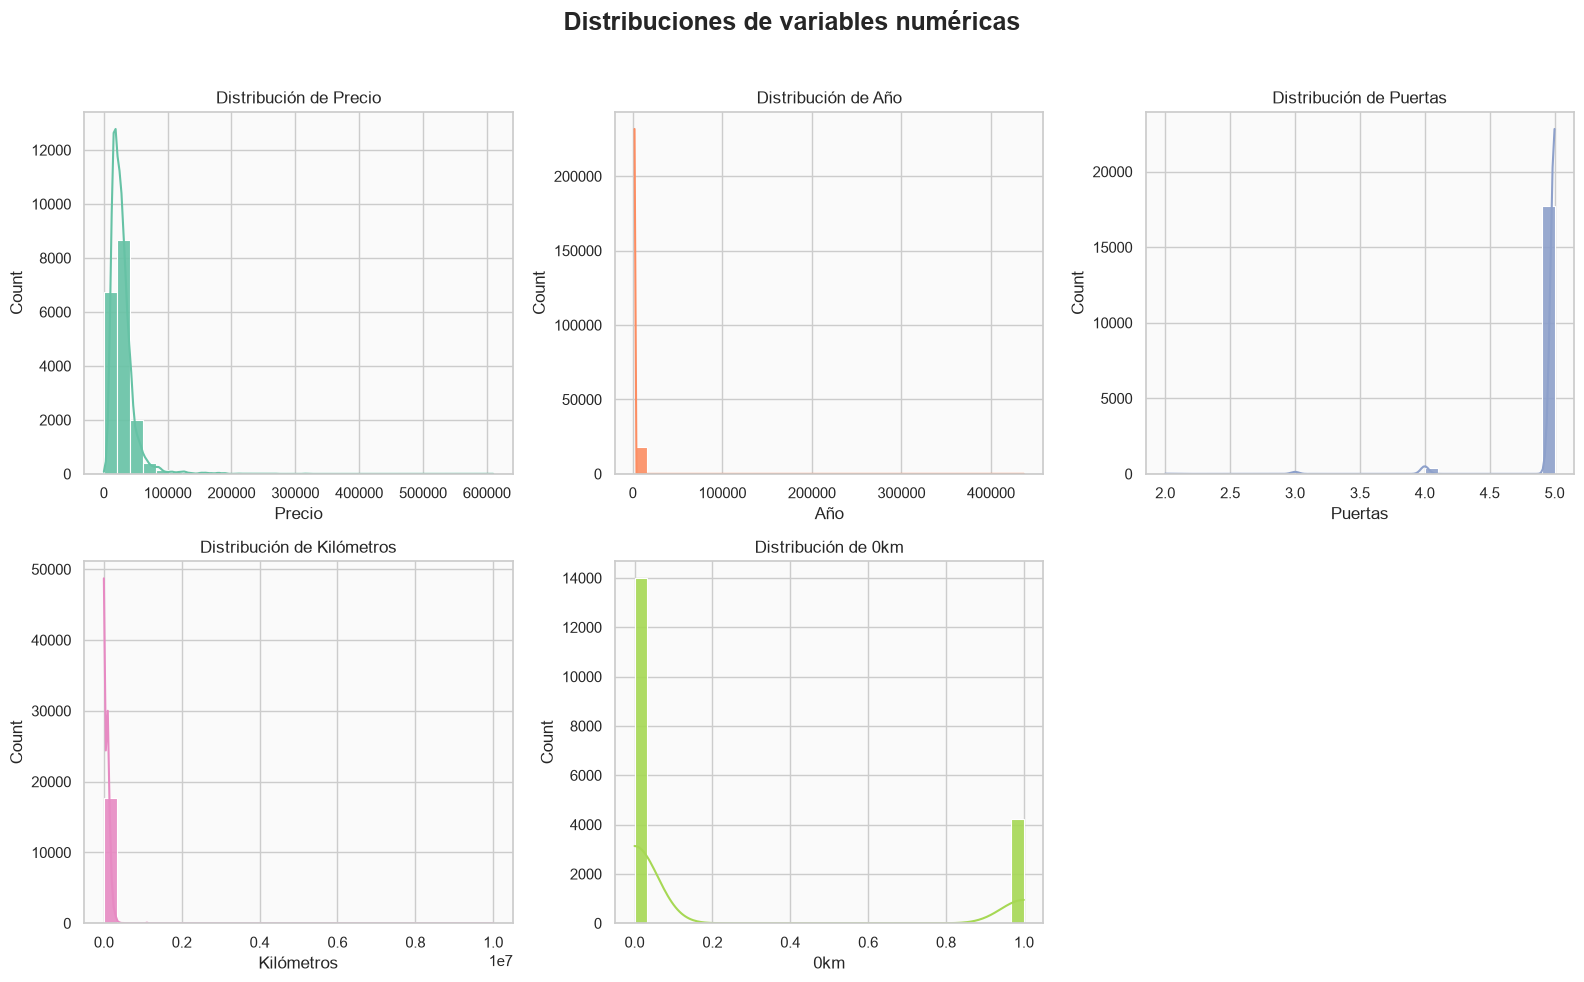

Boxplots individuales


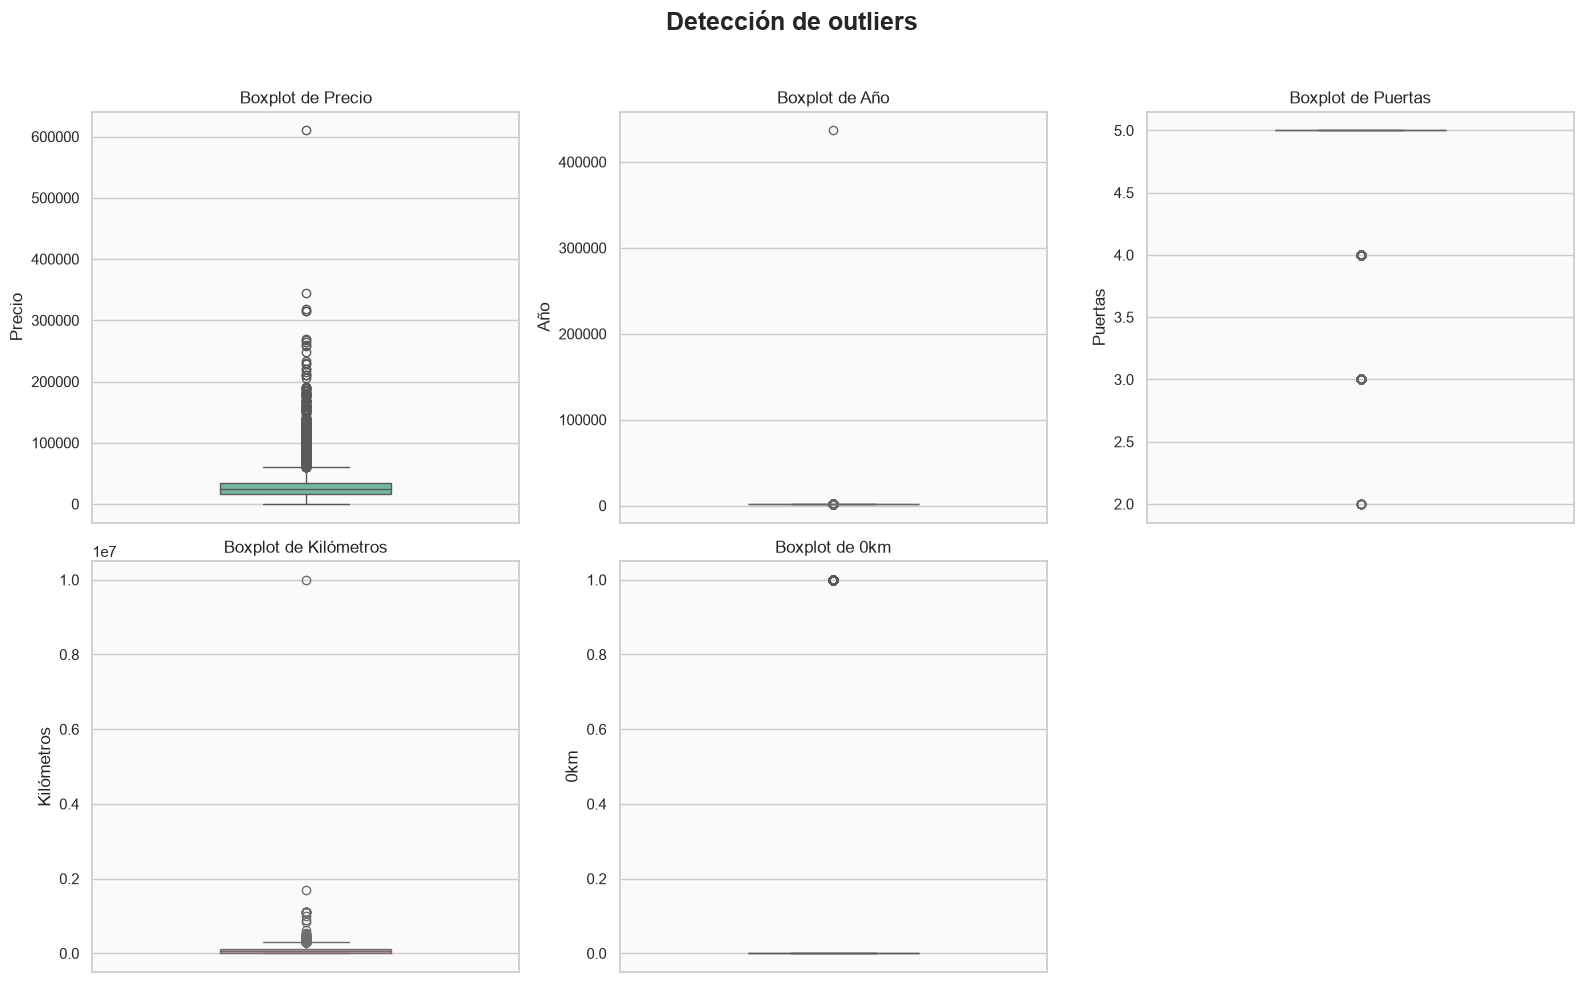

Relación con el precio


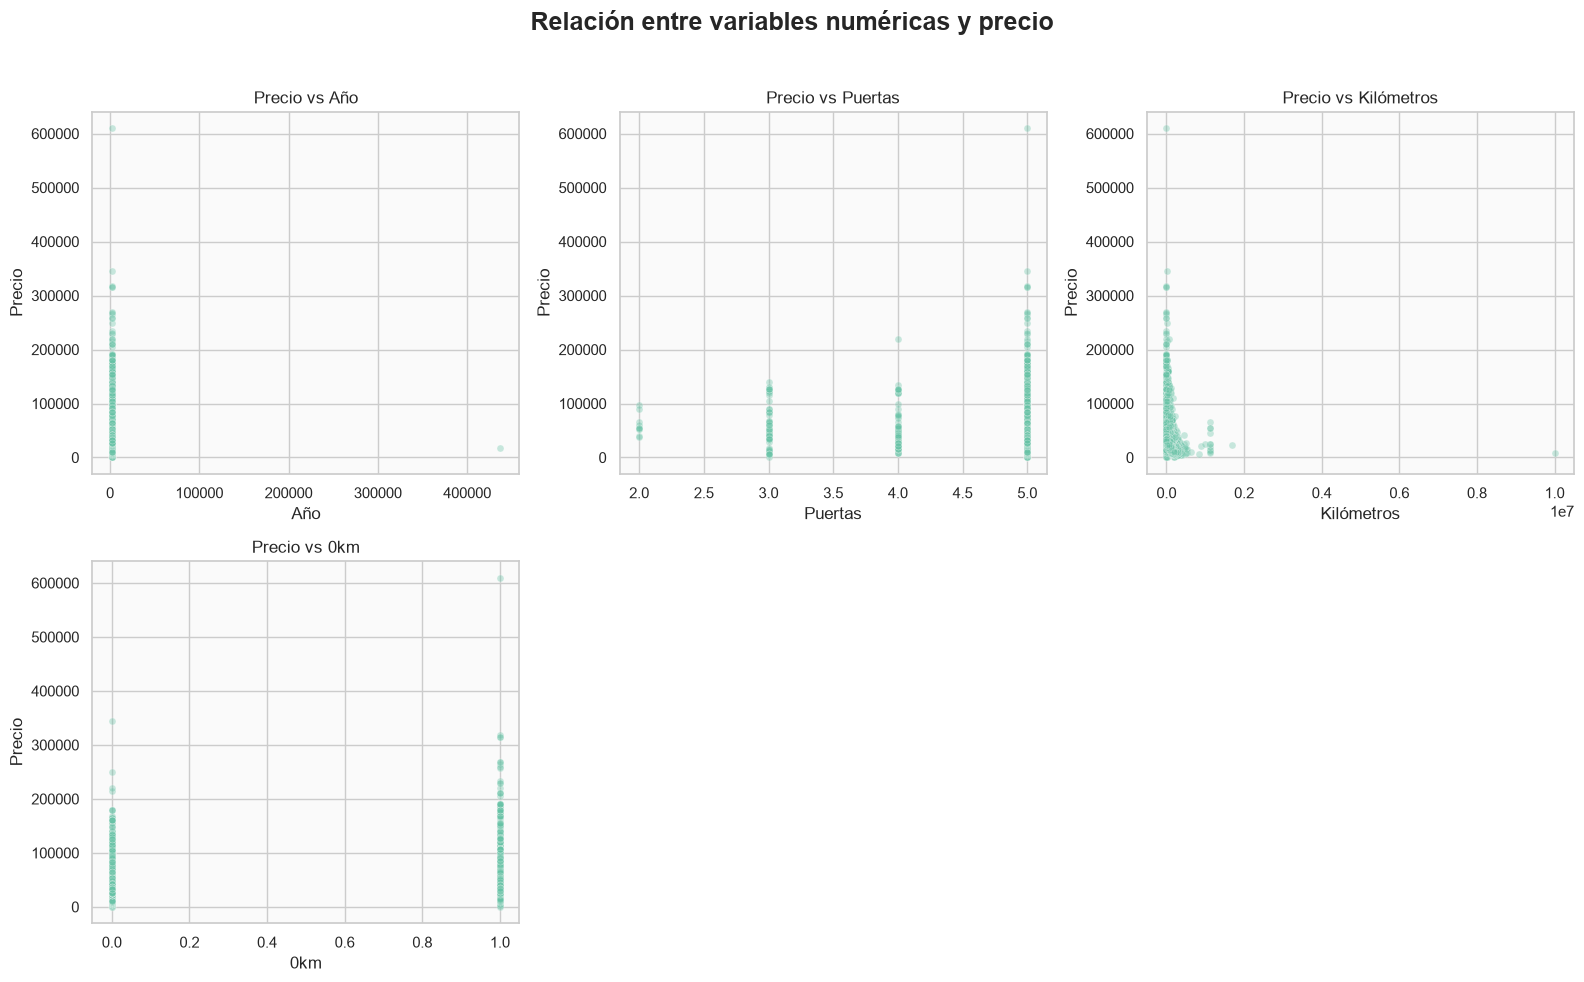

Relación de variables categóricas con el precio


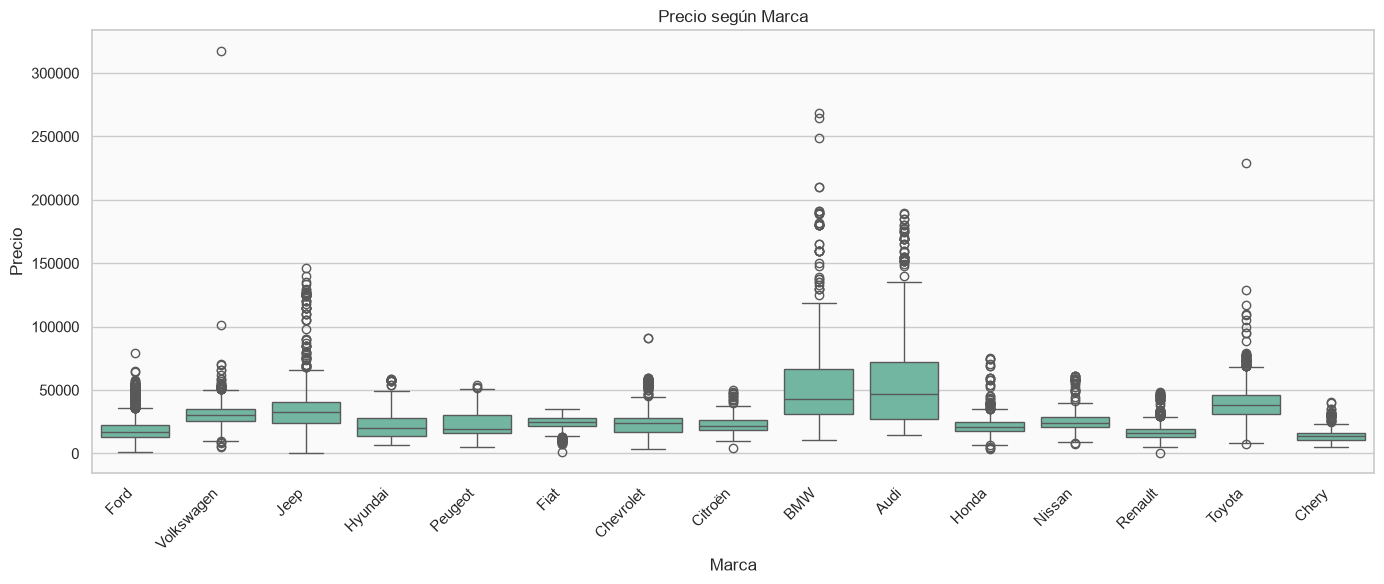

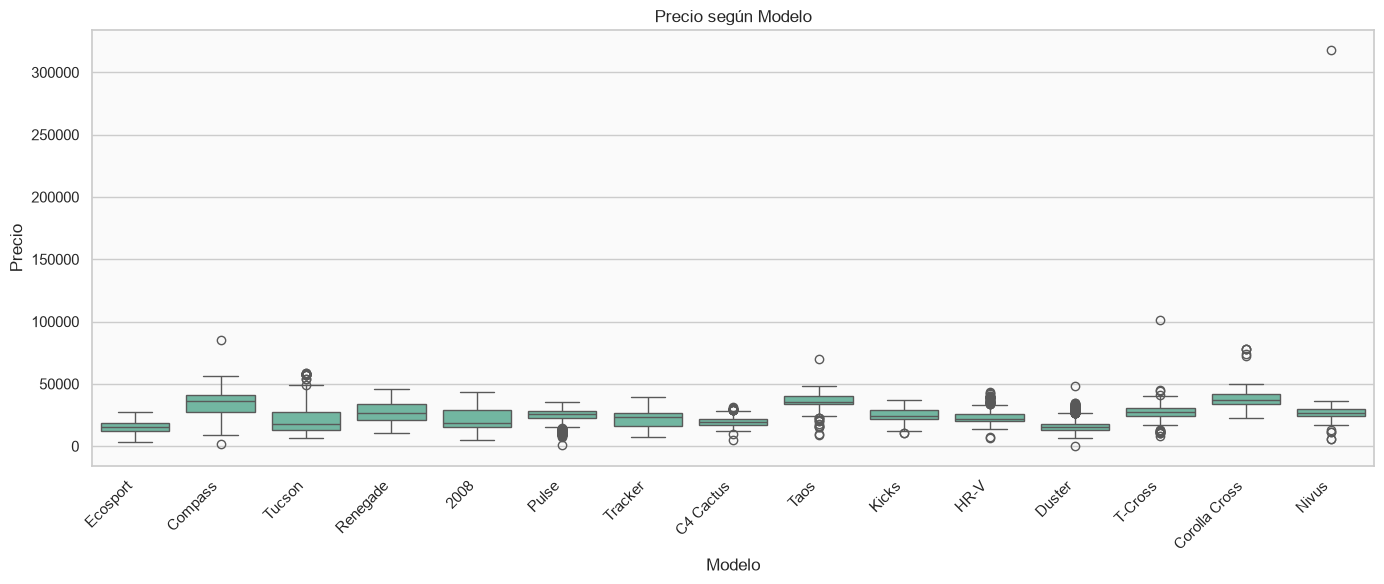

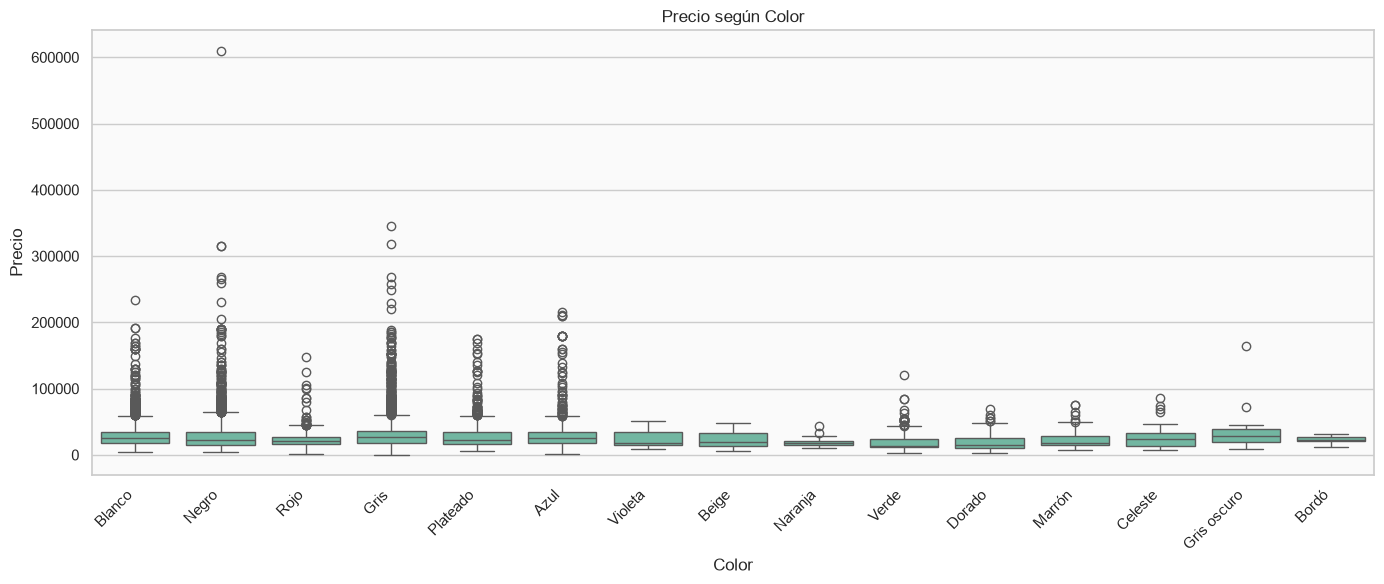

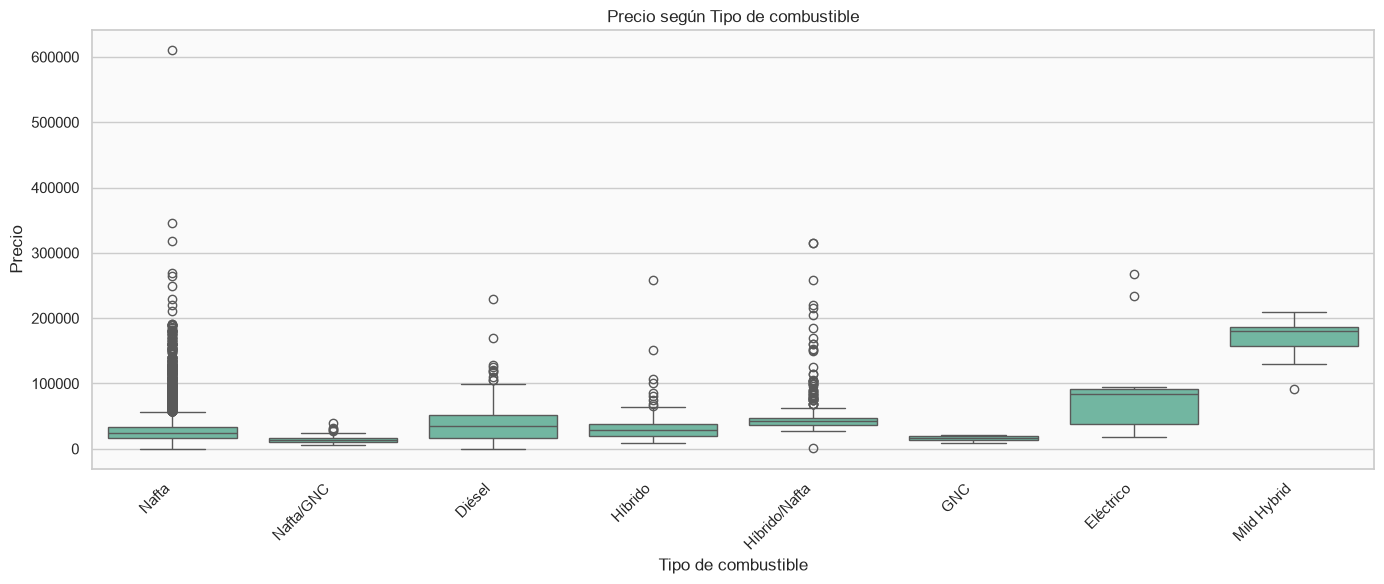

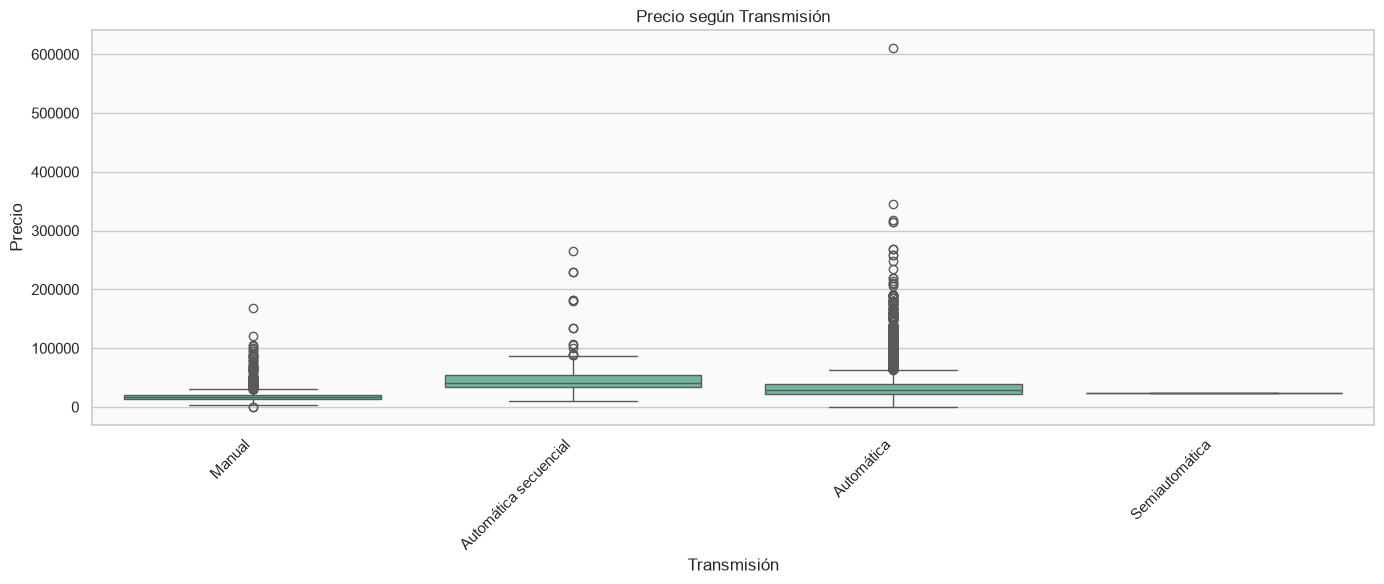

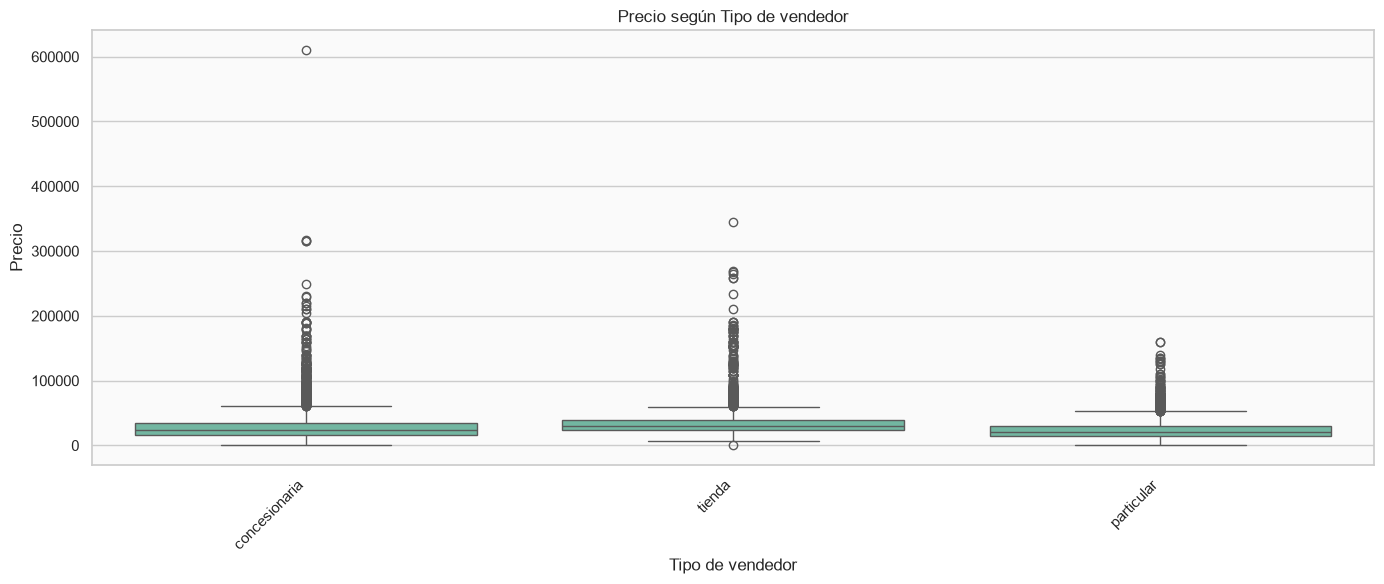

Matriz de correlación


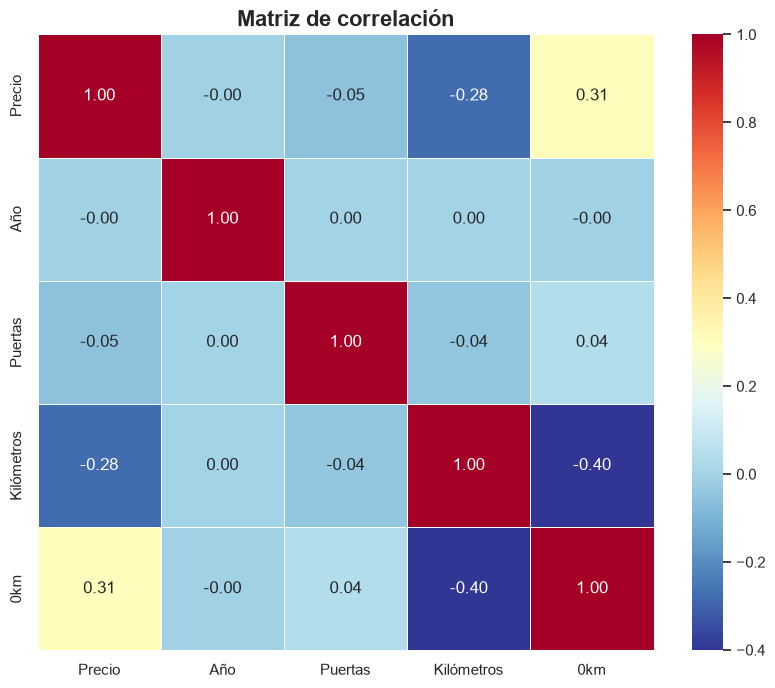

In [10]:
#Plots
eda_visualizacion_suvs(data_pre, target= "Precio", show_pairplot= False)

Para terminar con el ***preprocesamiento de datos***, se aplica el split para poder obtener la moda calculada sobre el conjunto de train, y asi poder completar los valores faltantes de las features "color", "transmision", "camara"  evitando el data leakage.

In [11]:
train, val = train_val_split(data_pre)

Tamaño conjunto de entrenamiento -> (14572, 16), 
Tamaño conjunto de validación -> (3644, 16)


In [12]:
#Preprocessing post split using the train parameters
train, val = preprocesamiento_post_split(train, val)

In [14]:
#One-Hot Encoding sobre las columnas con baja cardinalidad
columnas_oh = ['Tipo de combustible', 'Tipo de vendedor', 'Transmisión', 'Con cámara de retroceso']
train, val = onehot_encoding(train, val, columnas_oh)

In [ ]:
print('Final del preprocesamiento sobre Entrenamiento')
summary = pd.DataFrame({
    "dtype": train.dtypes,
    "nulos": train.isnull().sum(),
    "unicos": train.nunique()
})
summary

Final del preprocesamiento sobre Train


,dtype,nulos,unicos
Marca,str,0,43
Modelo,str,0,137
Año,float64,0,39
Versión,str,0,1853
Color,str,0,63
Puertas,float64,0,4
Motor,str,0,237
Kilómetros,float64,0,1849
Título,str,0,1976
Precio,float64,0,2522


In [21]:
print('Final del preprocesamiento sobre Validación')
summary = pd.DataFrame({
    "dtype": val.dtypes,
    "nulos": val.isnull().sum(),
    "unicos": val.nunique()
})
summary

Final del preprocesamiento sobre Validación


,dtype,nulos,unicos
Marca,str,0,39
Modelo,str,0,123
Año,float64,0,35
Versión,str,0,907
Color,str,0,33
Puertas,float64,0,4
Motor,str,0,105
Kilómetros,float64,0,750
Título,str,0,930
Precio,float64,0,1165


### MODELOS

### Comparison bewtween models

### Final Model